# ML Classification: Gesture Phase Segmentation
**MSc Data Science — Machine Learning Group Submission**
# Machine Learning Classification: Gesture Phase Segmentation

## MSc Data Science — Machine Learning Group Submission
# Coursework 1 Group 11

Group number: 11

Student names and k-numbers:
1. LALITH ADITYA DEVARAJ
2. SHALINI
3. THREYA
4. MATHANGI

# Load modules

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    balanced_accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score
)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
import lightgbm as lgb

# === KNN with Hyperparameter Tuning ===
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load data

In [18]:
dataset = fetch_openml(data_id=4538, as_frame=False)
X, y = dataset.data, dataset.target
CLASSES = np.unique(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
y_test_bin = label_binarize(y_test, classes=CLASSES)

print(f'Samples: {X.shape[0]}  Features: {X.shape[1]}  Classes: {list(CLASSES)}')
print(f'Train: {len(X_train)}  Test: {len(X_test)}')
classes_u, counts = np.unique(y, return_counts=True)
print(pd.DataFrame({'Class': classes_u, 'Count': counts, '%': (counts/len(y)*100).round(1)}).to_string(index=False))

Samples: 9873  Features: 32  Classes: ['D', 'H', 'P', 'R', 'S']
Train: 6911  Test: 2962
Class  Count    %
    D   2741 27.8
    H    998 10.1
    P   2097 21.2
    R   1087 11.0
    S   2950 29.9


# Classification

In [19]:
## Classification methods used

## We created these functions to avoid repeating the same evaluation steps across multiple models.
### **Purpose:** Keeps the notebook clean, avoids code duplication, and allows easy re-use across models.

1. `evaluate(name, y_true, y_pred, y_prob)`  
   - Calculates **balanced accuracy**, **macro AUC**, and **micro AUC**.  
   - Prints the **classification report**.  
   - Stores **ROC curves and metrics** in global dictionaries.  

2. `plot_confusion_matrix(name, y_true, y_pred)`  
   - Plots the **confusion matrix**, showing how many samples were correctly or incorrectly classified per class.  

In [20]:
all_results, all_roc_data = {}, {}

def evaluate(name, y_true, y_pred, y_prob):
    bal_acc   = balanced_accuracy_score(y_true, y_pred)
    macro_auc = roc_auc_score(y_test_bin, y_prob, average='macro', multi_class='ovr')
    micro_auc = roc_auc_score(y_test_bin, y_prob, average='micro')

    print(f'\n=== Evaluation Metrics: {name} ===\n')
    print(f'Balanced Accuracy: {bal_acc:.4f}  Macro AUC: {macro_auc:.4f}  Micro AUC: {micro_auc:.4f}')
    print(classification_report(y_true, y_pred, target_names=CLASSES))

    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred, labels=CLASSES), display_labels=CLASSES).plot(cmap='Purples')
    plt.title(f'Confusion Matrix - {name}')
    plt.tight_layout(); plt.show()

    fpr, tpr, roc_auc_vals = {}, {}, {}
    for i, cls in enumerate(CLASSES):
        fpr[cls], tpr[cls], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc_vals[cls] = auc(fpr[cls], tpr[cls])

    all_results[name] = {'balanced_accuracy': bal_acc, 'macro_auc': macro_auc, 'micro_auc': micro_auc}
    all_roc_data[name] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc_vals}

## Model 1: K-Nearest Neighbours
Instance-based learner classifying by majority vote among k nearest neighbours. Scale-sensitive — `StandardScaler` inside `Pipeline`. `GridSearchCV` over k, weights, and distance metric.

=== Hyperparameter Tuning: KNN ===

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params: {'estimator__metric': 'manhattan', 'estimator__n_neighbors': 1, 'estimator__weights': 'uniform'}  CV score: 0.6329

=== Evaluation Metrics: KNN ===

Balanced Accuracy: 0.6719  Macro AUC: 0.7960  Micro AUC: 0.8071
              precision    recall  f1-score   support

           D       0.74      0.80      0.77       822
           H       0.63      0.65      0.64       300
           P       0.65      0.61      0.63       629
           R       0.59      0.60      0.60       326
           S       0.74      0.69      0.71       885

    accuracy                           0.69      2962
   macro avg       0.67      0.67      0.67      2962
weighted avg       0.69      0.69      0.69      2962



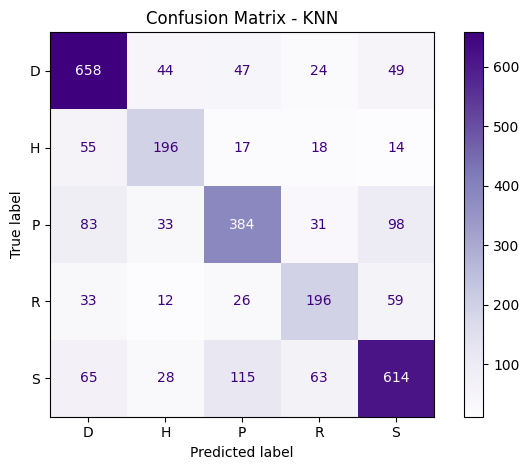

In [21]:
print("=== Hyperparameter Tuning: KNN ===\n")
knn_model = OneVsRestClassifier(KNeighborsClassifier(n_jobs=-1))
param_grid = {
    'estimator__n_neighbors': [1, 3, 5, 7, 9, 11, 15, 21, 31],
    'estimator__weights': ['uniform', 'distance'],
    'estimator__metric': ['euclidean', 'manhattan', 'minkowski']
}
knn_search = GridSearchCV(knn_model, param_grid,cv=5, scoring='balanced_accuracy', n_jobs=-1, verbose=1)
knn_search.fit(X_train, y_train)
print(f'Best params: {knn_search.best_params_}  CV score: {knn_search.best_score_:.4f}')
evaluate('KNN', y_test, knn_search.best_estimator_.predict(X_test), knn_search.best_estimator_.predict_proba(X_test)
)

## Model 2: Support Vector Machine (RBF Kernel)
SVM with RBF kernel finds an optimal separating hyperplane in high-dimensional space. `StandardScaler` is applied inside a `Pipeline`. `RandomizedSearchCV` explores C and gamma.

=== Hyperparameter Tuning: SVM (RBF) 
===
Fitting 3 folds for each of 64 candidates, totalling 192 fits
Best params: {'estimator__C': 100, 'estimator__gamma': 'scale'}  CV score: 0.4924

=== Evaluation Metrics: SVM (RBF) ===

Balanced Accuracy: 0.5144  Macro AUC: 0.8063  Micro AUC: 0.8356
              precision    recall  f1-score   support

           D       0.57      0.87      0.69       822
           H       0.50      0.19      0.28       300
           P       0.56      0.48      0.51       629
           R       0.58      0.44      0.50       326
           S       0.66      0.58      0.62       885

    accuracy                           0.59      2962
   macro avg       0.57      0.51      0.52      2962
weighted avg       0.59      0.59      0.57      2962



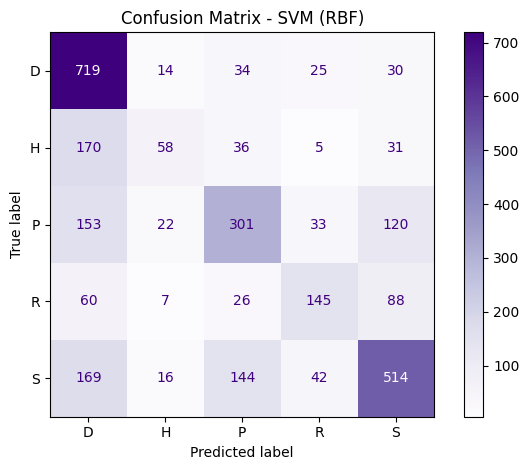

In [22]:
print("=== Hyperparameter Tuning: SVM (RBF) \n===")
svm_model = OneVsRestClassifier(SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE))
param_grid = {
    'estimator__C': [0.01, 0.1, 0.5, 1, 5, 10, 50, 100],
    'estimator__gamma': ['scale', 'auto', 0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
}
svm_search = GridSearchCV(svm_model, param_grid, cv=3, scoring='balanced_accuracy', n_jobs=-1, verbose=1)
svm_search.fit(X_train, y_train)
print(f'Best params: {svm_search.best_params_}  CV score: {svm_search.best_score_:.4f}')
evaluate('SVM (RBF)', y_test, svm_search.best_estimator_.predict(X_test), svm_search.best_estimator_.predict_proba(X_test)
)

## Model 2: Random Forest
Ensemble of decision trees trained on bootstrapped subsets with random feature selection. No scaling required. `RandomizedSearchCV` over tree structure hyperparameters.

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 30}  CV score: 0.5678

=== Evaluation Metrics: Random Forest ===

Balanced Accuracy: 0.5929  Macro AUC: 0.8935  Micro AUC: 0.9034
              precision    recall  f1-score   support

           D       0.67      0.87      0.76       822
           H       0.83      0.37      0.51       300
           P       0.68      0.51      0.58       629
           R       0.65      0.45      0.53       326
           S       0.64      0.77      0.70       885

    accuracy                           0.67      2962
   macro avg       0.69      0.59      0.62      2962
weighted avg       0.68      0.67      0.65      2962



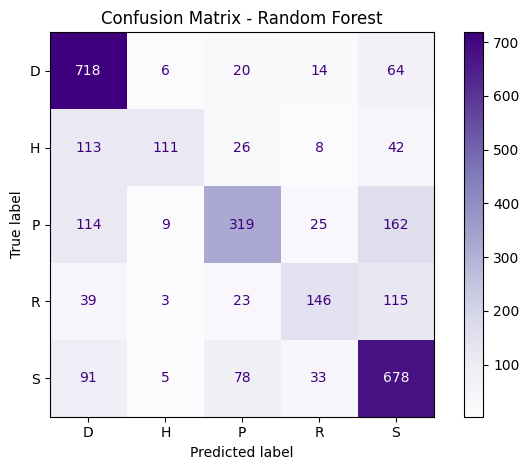

In [23]:
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    {'n_estimators': [50, 100, 200, 300, 500], 'max_depth': [None, 5, 10, 20, 30],
     'min_samples_split': [2, 5, 10, 20], 'min_samples_leaf': [1, 2, 4, 8],
     'max_features': ['sqrt', 'log2', 0.3, 0.5]},
    n_iter=40, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='balanced_accuracy', n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
rf_search.fit(X_train, y_train)
print(f'Best params: {rf_search.best_params_}  CV score: {rf_search.best_score_:.4f}')
evaluate('Random Forest', y_test,rf_search.best_estimator_.predict(X_test), rf_search.best_estimator_.predict_proba(X_test))

# Model 4: LightGBM

=== Hyperparameter Tuning ===

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'subsample': 0.7, 'num_leaves': 127, 'n_estimators': 500, 'min_child_samples': 50, 'max_depth': -1, 'learning_rate': 0.2, 'colsample_bytree': 0.6}  CV score: 0.6228

=== Evaluation Metrics: LightGBM ===

Balanced Accuracy: 0.6549  Macro AUC: 0.9101  Micro AUC: 0.9199
              precision    recall  f1-score   support

           D       0.74      0.87      0.80       822
           H       0.71      0.54      0.61       300
           P       0.69      0.58      0.63       629
           R       0.63      0.52      0.57       326
           S       0.70      0.77      0.73       885

    accuracy                           0.71      2962
   macro avg       0.69      0.65      0.67      2962
weighted avg       0.70      0.71      0.70      2962



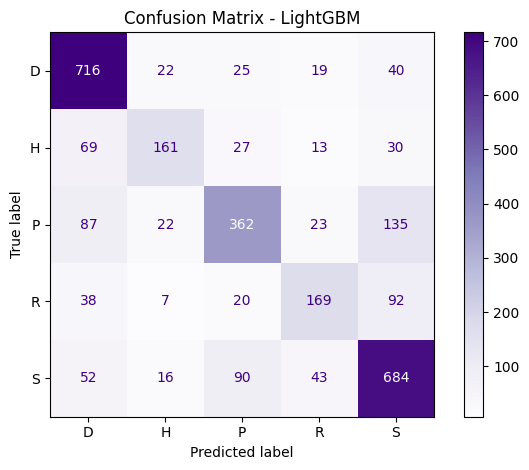

In [24]:
lgbm_search = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
    {'n_estimators': [50, 100, 200, 300, 500], 'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
     'num_leaves': [15, 31, 63, 127], 'max_depth': [-1, 3, 5, 7, 10],
     'min_child_samples': [10, 20, 30, 50],
     'subsample': [0.6, 0.7, 0.8, 0.9, 1.0], 'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]},
    n_iter=40, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='balanced_accuracy', n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
print("=== Hyperparameter Tuning ===\n")
lgbm_search.fit(X_train, y_train)
print(f'Best params: {lgbm_search.best_params_}  CV score: {lgbm_search.best_score_:.4f}')
evaluate('LightGBM', y_test,
         lgbm_search.best_estimator_.predict(X_test),
         lgbm_search.best_estimator_.predict_proba(X_test))

# XGBoost

=== Hyperparameter Tuning: XGBoost ===

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

=== Evaluation Metrics: XGBoost ===

Balanced Accuracy: 0.6395  Macro AUC: 0.9047  Micro AUC: 0.9156
              precision    recall  f1-score   support

           D       0.73      0.86      0.79       822
           H       0.74      0.50      0.60       300
           P       0.68      0.57      0.62       629
           R       0.67      0.48      0.56       326
           S       0.67      0.79      0.72       885

    accuracy                           0.70      2962
   macro avg       0.70      0.64      0.66      2962
weighted avg       0.70      0.70      0.69      2962



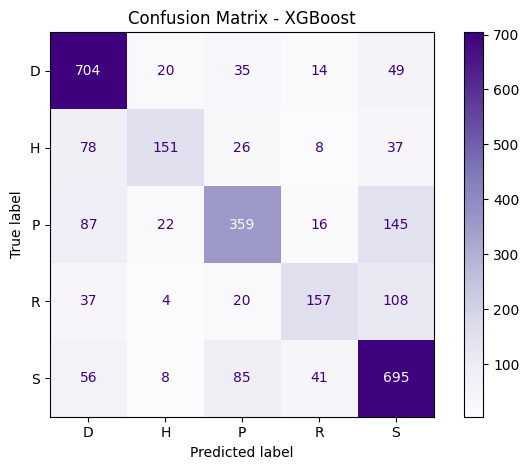

Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}  CV score: 0.6042


In [25]:
from sklearn.preprocessing import LabelEncoder  # <-- this is required
# Encode labels
le = LabelEncoder()
y_train_enc, y_test_enc = le.fit_transform(y_train), le.transform(y_test)

param_grid = {
    'n_estimators':[50,100,200],
    'learning_rate':[0.01,0.05,0.1,0.2],
    'max_depth':[3,5,7],
    'subsample':[0.6,0.8,1.0],
    'colsample_bytree':[0.6,0.8,1.0]
}
print("=== Hyperparameter Tuning: XGBoost ===\n")
xgb_search = GridSearchCV(
    XGBClassifier(objective='multi:softprob', use_label_encoder=False, eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), scoring='balanced_accuracy', n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train_enc)
evaluate('XGBoost', y_test, le.inverse_transform(xgb_search.predict(X_test)), xgb_search.predict_proba(X_test))
print(f'Best params: {xgb_search.best_params_}  CV score: {xgb_search.best_score_:.4f}')

# Model 5: Extra Trees
Like Random Forest but with fully randomised split thresholds. Lower variance, faster training. No scaling required. Same hyperparameter space as Random Forest.

=== Hyperparameter Tuning: Extra Trees ===

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 30}  CV score: 0.5819

=== Evaluation Metrics: Extra Trees ===

Balanced Accuracy: 0.6096  Macro AUC: 0.9063  Micro AUC: 0.9130
              precision    recall  f1-score   support

           D       0.69      0.89      0.78       822
           H       0.92      0.40      0.56       300
           P       0.70      0.52      0.60       629
           R       0.72      0.43      0.54       326
           S       0.64      0.80      0.71       885

    accuracy                           0.69      2962
   macro avg       0.73      0.61      0.64      2962
weighted avg       0.70      0.69      0.67      2962



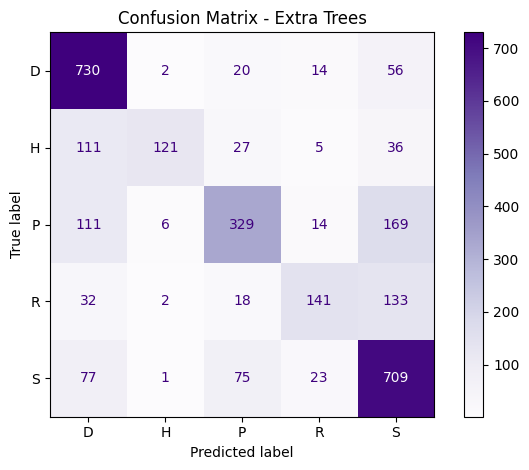

In [26]:
print("=== Hyperparameter Tuning: Extra Trees ===\n")
et_model = ExtraTreesClassifier(random_state=RANDOM_STATE,n_jobs=-1)
param_dist = {
    'n_estimators':[50,100,200,300,500],
    'max_depth':[None,5,10,20,30],
    'min_samples_split':[2,5,10,20],
    'min_samples_leaf':[1,2,4,8],
    'max_features':['sqrt','log2',0.3,0.5]
}
et_search = RandomizedSearchCV(et_model,param_distributions=param_dist,n_iter=40,cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE),scoring='balanced_accuracy',n_jobs=-1,random_state=RANDOM_STATE,verbose=1)
et_search.fit(X_train,y_train)
print(f'Best params: {et_search.best_params_}  CV score: {et_search.best_score_:.4f}')
evaluate('Extra Trees',y_test,et_search.best_estimator_.predict(X_test),et_search.best_estimator_.predict_proba(X_test))

# Model 6: Multi-Layer Perceptron
Feedforward neural network trained with backpropagation. Scale-sensitive — `StandardScaler` inside `Pipeline`. `RandomizedSearchCV` over architecture and regularisation.

=== Hyperparameter Tuning ===

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'clf__learning_rate': 'adaptive', 'clf__hidden_layer_sizes': (256, 128), 'clf__alpha': 0.01, 'clf__activation': 'tanh'}  CV score: 0.5324

=== Evaluation Metrics: MLP ===

Balanced Accuracy: 0.5677  Macro AUC: 0.8123  Micro AUC: 0.8298
              precision    recall  f1-score   support

           D       0.68      0.76      0.72       822
           H       0.52      0.49      0.51       300
           P       0.52      0.51      0.51       629
           R       0.50      0.49      0.49       326
           S       0.64      0.59      0.61       885

    accuracy                           0.60      2962
   macro avg       0.57      0.57      0.57      2962
weighted avg       0.60      0.60      0.60      2962



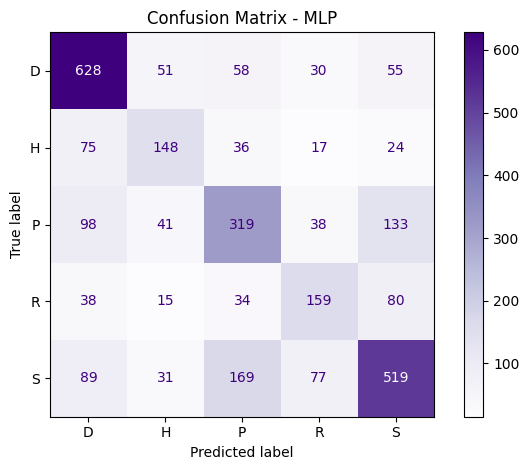

In [27]:
mlp_search = RandomizedSearchCV(
    Pipeline([('scaler', StandardScaler()), ('clf', MLPClassifier(max_iter=500, random_state=RANDOM_STATE))]),
    {'clf__hidden_layer_sizes': [(64,), (128,), (256,), (64, 64), (128, 64),
                                  (128, 128), (256, 128), (64, 64, 32)],
     'clf__activation': ['relu', 'tanh'],
     'clf__alpha': [1e-5, 1e-4, 1e-3, 0.01, 0.1],
     'clf__learning_rate': ['constant', 'adaptive']},
    n_iter=30, cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='balanced_accuracy', n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
print("=== Hyperparameter Tuning ===\n")
mlp_search.fit(X_train, y_train)
print(f'Best params: {mlp_search.best_params_}  CV score: {mlp_search.best_score_:.4f}')
evaluate('MLP', y_test,
         mlp_search.best_estimator_.predict(X_test),
         mlp_search.best_estimator_.predict_proba(X_test))

# Model 8: Naive Bayes (Gaussian)
Applies Bayes' theorem assuming conditional feature independence. `GridSearchCV` over `var_smoothing` to stabilise covariance estimates.

=== Hyperparameter Tuning: Naive Bayes ===

Fitting 5 folds for each of 11 candidates, totalling 55 fits
Best params: {'var_smoothing': 0.0001}  CV score: 0.3430

=== Evaluation Metrics: Naive Bayes ===

Balanced Accuracy: 0.3421  Macro AUC: 0.7101  Micro AUC: 0.7121
              precision    recall  f1-score   support

           D       0.45      0.85      0.59       822
           H       0.12      0.13      0.12       300
           P       0.41      0.24      0.30       629
           R       0.25      0.15      0.19       326
           S       0.57      0.35      0.43       885

    accuracy                           0.42      2962
   macro avg       0.36      0.34      0.33      2962
weighted avg       0.42      0.42      0.39      2962



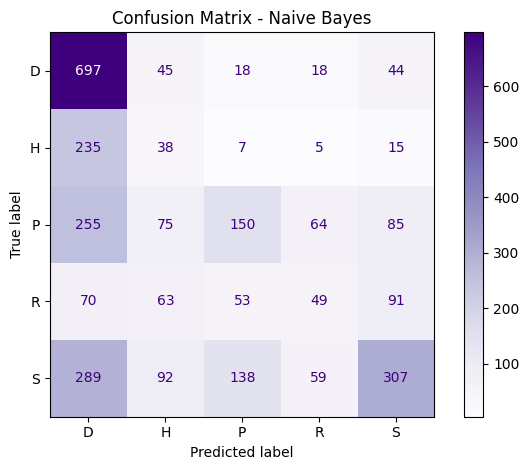

In [28]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV, StratifiedKFold

print("=== Hyperparameter Tuning: Naive Bayes ===\n")
nb_model = GaussianNB()
param_grid = {'var_smoothing':[1e-11,1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1]}
nb_search = GridSearchCV(nb_model,param_grid,cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE),scoring='balanced_accuracy',n_jobs=-1,verbose=1)
nb_search.fit(X_train,y_train)
print(f'Best params: {nb_search.best_params_}  CV score: {nb_search.best_score_:.4f}')
evaluate('Naive Bayes',y_test,nb_search.best_estimator_.predict(X_test),nb_search.best_estimator_.predict_proba(X_test))

# Model 9: Logistic Regression
Linear classifier modelling log-odds with multinomial softmax. `GridSearchCV` handles the solver–penalty interaction via a list of parameter grids. Scaling inside `Pipeline`.

=== Hyperparameter Tuning: Logistic Regression ===

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'C': 1000, 'penalty': 'l1', 'solver': 'saga'}  CV score: 0.3648

=== Evaluation Metrics: Logistic Regression ===

Balanced Accuracy: 0.3567  Macro AUC: 0.7614  Micro AUC: 0.7893
              precision    recall  f1-score   support

           D       0.47      0.86      0.61       822
           H       0.37      0.03      0.06       300
           P       0.53      0.28      0.36       629
           R       0.39      0.08      0.13       326
           S       0.46      0.53      0.49       885

    accuracy                           0.47      2962
   macro avg       0.44      0.36      0.33      2962
weighted avg       0.46      0.47      0.41      2962



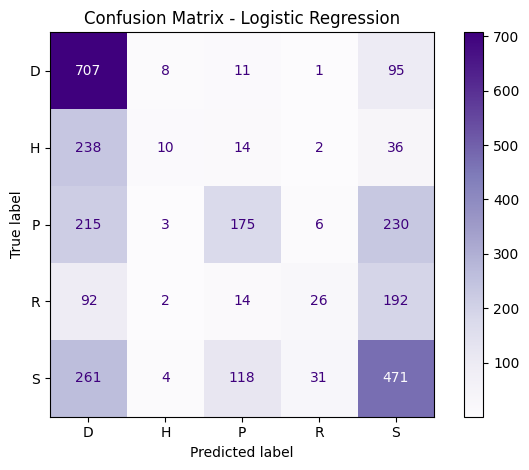

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

print("=== Hyperparameter Tuning: Logistic Regression ===\n")
lr_model = LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)
param_grid = [
    {'C':[0.0001,0.001,0.01,0.1,1,10,100,1000],'solver':['lbfgs'],'penalty':['l2']},
    {'C':[0.0001,0.001,0.01,0.1,1,10,100,1000],'solver':['saga'],'penalty':['l1','l2']}
]
lr_search = GridSearchCV(lr_model,param_grid,cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE),scoring='balanced_accuracy',n_jobs=-1,verbose=1)
lr_search.fit(X_train,y_train)
print(f'Best params: {lr_search.best_params_}  CV score: {lr_search.best_score_:.4f}')
evaluate('Logistic Regression',y_test,lr_search.best_estimator_.predict(X_test),lr_search.best_estimator_.predict_proba(X_test))

# Gradient Boosting

=== Hyperparameter Tuning: Gradient Boosting ===

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.6}  CV score: 0.5881

=== Evaluation Metrics: Gradient Boosting ===

Balanced Accuracy: 0.6109  Macro AUC: 0.8920  Micro AUC: 0.9044
              precision    recall  f1-score   support

           D       0.72      0.86      0.78       822
           H       0.68      0.45      0.54       300
           P       0.65      0.56      0.60       629
           R       0.66      0.44      0.52       326
           S       0.65      0.75      0.70       885

    accuracy                           0.67      2962
   macro avg       0.67      0.61      0.63      2962
weighted avg       0.67      0.67      0.67      2962



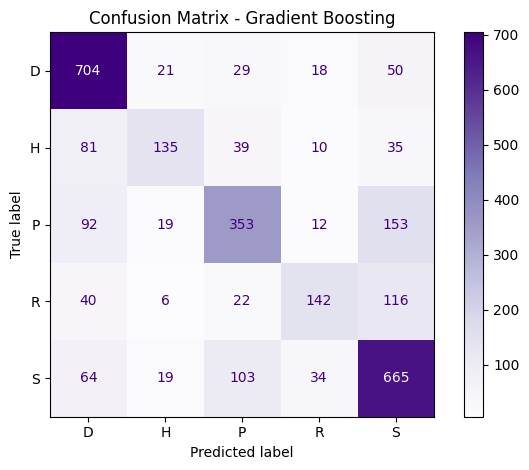

In [30]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

print("=== Hyperparameter Tuning: Gradient Boosting ===\n")
gb_model = GradientBoostingClassifier(random_state=RANDOM_STATE)
param_grid = {
    'n_estimators':[50,100,200],
    'learning_rate':[0.01,0.05,0.1,0.2],
    'max_depth':[3,5,7],
    'subsample':[0.6,0.8,1.0]
}
gb_search = GridSearchCV(gb_model,param_grid,cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE),scoring='balanced_accuracy',n_jobs=-1,verbose=1)
gb_search.fit(X_train,y_train)
print(f'Best params: {gb_search.best_params_}  CV score: {gb_search.best_score_:.4f}')
evaluate('Gradient Boosting',y_test,gb_search.best_estimator_.predict(X_test),gb_search.best_estimator_.predict_proba(X_test))

# DecisionTree

=== Hyperparameter Tuning: Decision Tree ===

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best params: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}  CV score: 0.4513

=== Evaluation Metrics: Decision Tree ===

Balanced Accuracy: 0.4487  Macro AUC: 0.7055  Micro AUC: 0.7349
              precision    recall  f1-score   support

           D       0.60      0.63      0.61       822
           H       0.33      0.34      0.34       300
           P       0.43      0.44      0.43       629
           R       0.36      0.32      0.34       326
           S       0.53      0.51      0.52       885

    accuracy                           0.49      2962
   macro avg       0.45      0.45      0.45      2962
weighted avg       0.49      0.49      0.49      2962



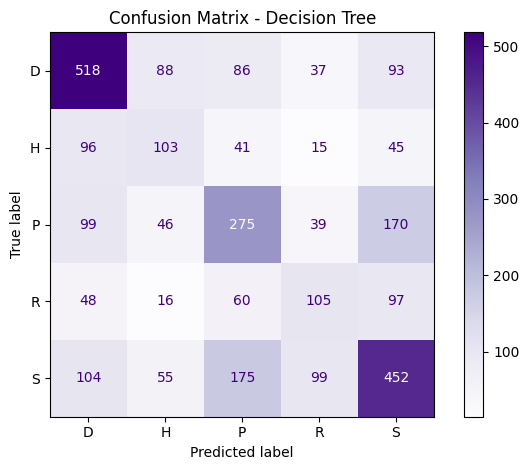

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

print("=== Hyperparameter Tuning: Decision Tree ===\n")
dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
param_grid = {
    'max_depth':[None,3,5,7,10],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}
dt_search = GridSearchCV(dt_model,param_grid,cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE),scoring='balanced_accuracy',n_jobs=-1,verbose=1)
dt_search.fit(X_train,y_train)
print(f'Best params: {dt_search.best_params_}  CV score: {dt_search.best_score_:.4f}')
evaluate('Decision Tree',y_test,dt_search.best_estimator_.predict(X_test),dt_search.best_estimator_.predict_proba(X_test))

## Final Comparison

                     Bal. Acc  Macro AUC  Micro AUC
LightGBM               0.6549     0.9101     0.9199
Extra Trees            0.6096     0.9063     0.9130
XGBoost                0.6395     0.9047     0.9156
Random Forest          0.5929     0.8935     0.9034
Gradient Boosting      0.6109     0.8920     0.9044
MLP                    0.5677     0.8123     0.8298
SVM (RBF)              0.5144     0.8063     0.8356
KNN                    0.6719     0.7960     0.8071
Logistic Regression    0.3567     0.7614     0.7893
Naive Bayes            0.3421     0.7101     0.7121
Decision Tree          0.4487     0.7055     0.7349


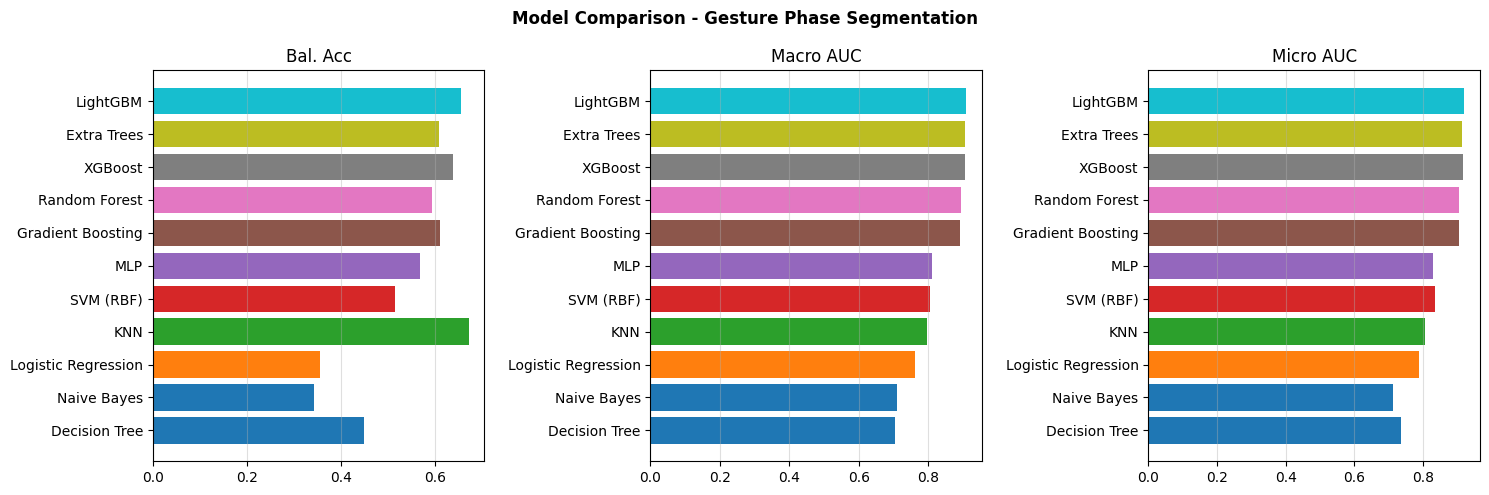

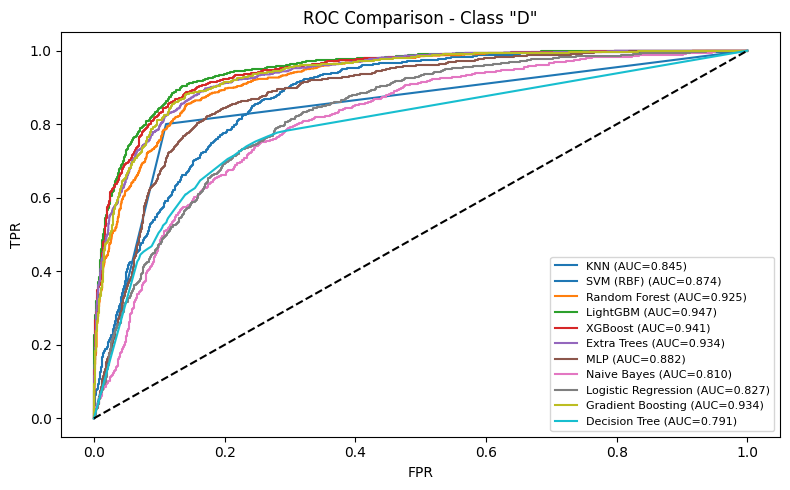

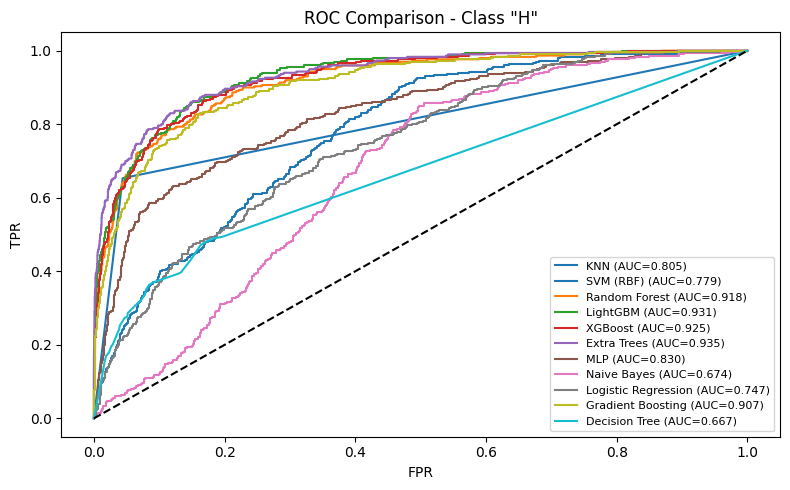

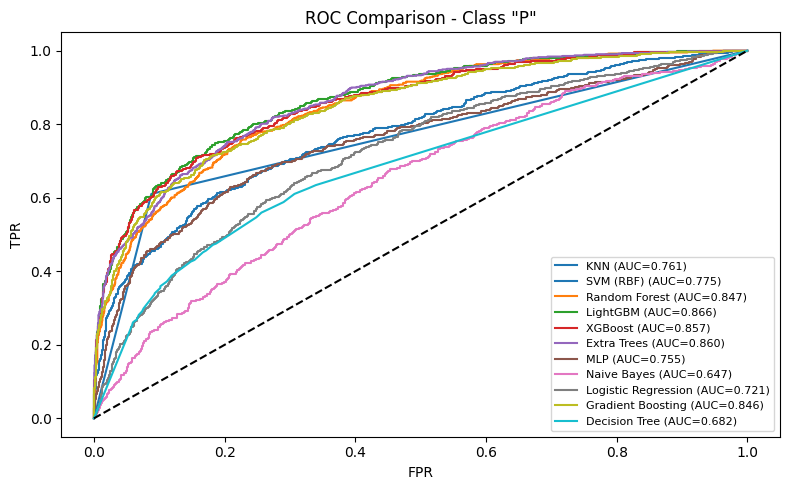

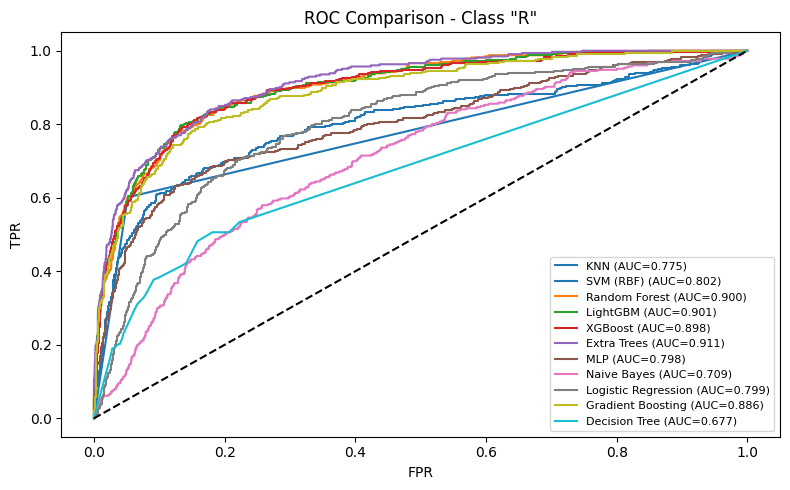

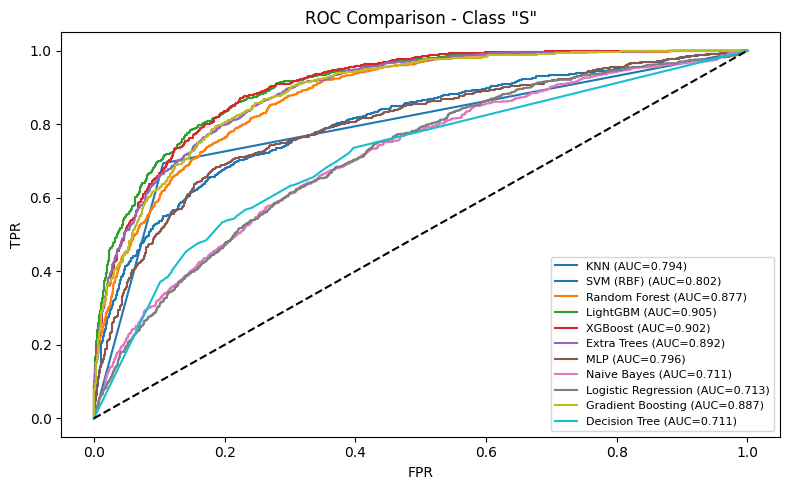

In [34]:
summary = pd.DataFrame(all_results).T
summary.columns = ['Bal. Acc', 'Macro AUC', 'Micro AUC']
summary = summary.sort_values('Macro AUC', ascending=False)
print(summary.round(4).to_string())

colors = plt.cm.tab10(np.linspace(0, 0.9, len(summary)))
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['Bal. Acc', 'Macro AUC', 'Micro AUC']):
    ax.barh(summary.index[::-1], summary[col][::-1], color=colors)
    ax.set_title(col); ax.grid(axis='x', alpha=0.4)
plt.suptitle('Model Comparison - Gesture Phase Segmentation', fontweight='bold')
plt.tight_layout(); plt.show()

plot_colors = plt.cm.tab10(np.linspace(0, 0.9, len(all_roc_data)))
for cls in CLASSES:
    fig, ax = plt.subplots(figsize=(8, 5))
    for (name, data), color in zip(all_roc_data.items(), plot_colors):
        ax.plot(data['fpr'][cls], data['tpr'][cls], color=color,
                label=f'{name} (AUC={data["auc"][cls]:.3f})')
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC Comparison - Class "{cls}"')
    ax.legend(loc='lower right', fontsize=8)
    plt.tight_layout(); plt.show()

In [ ]:
summary = pd.DataFrame(all_results).T
summary.columns = ['Bal. Acc', 'Macro AUC', 'Micro AUC']
summary = summary.sort_values('Macro AUC', ascending=False)
print(summary.round(4).to_string())

colors = plt.cm.tab10(np.linspace(0, 0.9, len(summary)))
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['Bal. Acc', 'Macro AUC', 'Micro AUC']):
    ax.barh(summary.index[::-1], summary[col][::-1], color=colors)
    ax.set_title(col); ax.grid(axis='x', alpha=0.4)
plt.suptitle('Model Comparison - Gesture Phase Segmentation', fontweight='bold')
plt.tight_layout(); plt.show()

plot_colors = plt.cm.tab10(np.linspace(0, 0.9, len(all_roc_data)))
for cls in CLASSES:
    fig, ax = plt.subplots(figsize=(8, 5))
    for (name, data), color in zip(all_roc_data.items(), plot_colors):
        ax.plot(data['fpr'][cls], data['tpr'][cls], color=color,
                label=f'{name} (AUC={data["auc"][cls]:.3f})')
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC Comparison - Class "{cls}"')
    ax.legend(loc='lower right', fontsize=8)
    plt.tight_layout(); plt.show()

In [ ]:
# Final Summary